In [22]:
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

from astropy.io import fits

In [23]:
f356w = fits.open('/Users/sshapiro/Desktop/356w DATA.fits')
f356w['SCI'].data.shape

(2505, 5639)

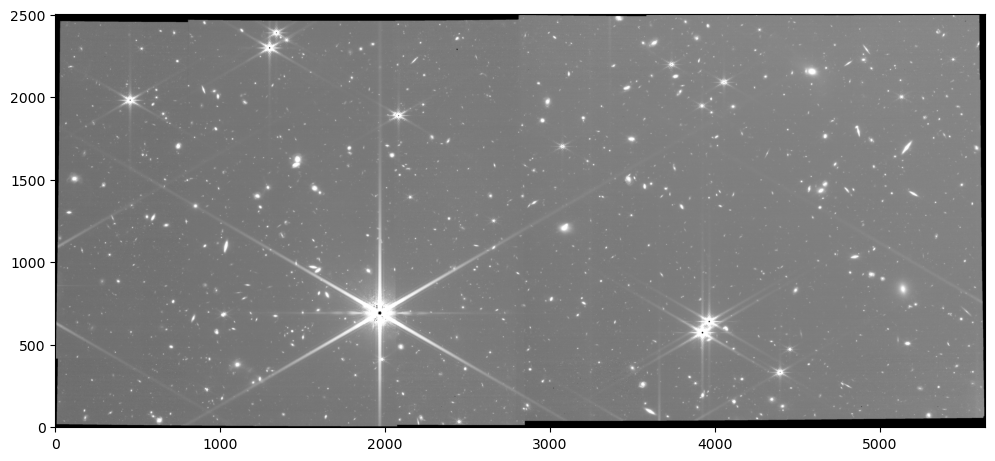

In [24]:
from astropy.visualization import simple_norm
plt.figure(figsize = [12,12])
norm = simple_norm(f356w['SCI'].data, 'asinh', percent = 99.)

plt.imshow(f356w['SCI'].data, origin = 'lower', norm=norm, cmap='grey')
#plt.colorbar()

In [25]:
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
sigma_clip = SigmaClip(sigma=4.5)
bkg_estimator = MedianBackground()
bkg = Background2D(f356w['SCI'].data, (200, 200), filter_size=(3, 3),sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)

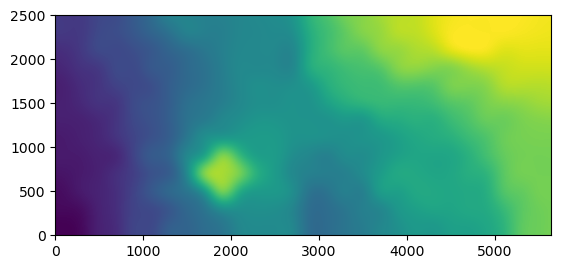

In [26]:
plt.imshow(bkg.background, origin='lower', interpolation='nearest')

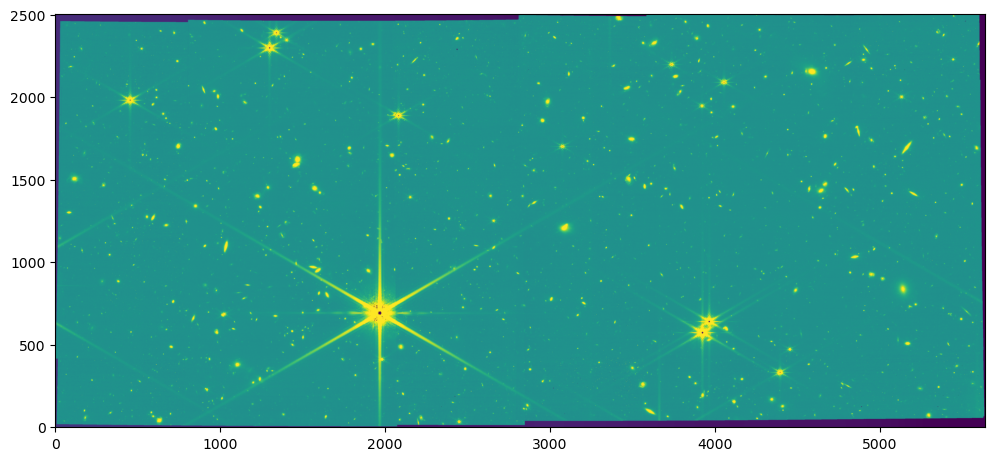

In [27]:
from astropy.visualization import simple_norm
plt.figure(figsize = [12,12])
norm = simple_norm(f356w['SCI'].data - bkg.background, 'asinh', percent = 99)

plt.imshow(f356w['SCI'].data - bkg.background, origin = 'lower', norm = norm)

In [28]:
from jdaviz import Imviz
imviz = Imviz()
imviz.show()

Application(config='imviz', docs_link='https://jdaviz.readthedocs.io/en/v4.2.2/imviz/index.html', events=['cal…

In [29]:
filenames = ['/Users/sshapiro/Desktop/f070w DATA.fits', 
             '/Users/sshapiro/Desktop/115w DATA.fits', 
             '/Users/sshapiro/Desktop/356w DATA.fits', 
             '/Users/sshapiro/Desktop/jw01160-o022_t011_nircam_clear-f444w_i2d.fits copy']
#with imviz.batch_load():  # not necessary, but this context manager makes loading multiple files more efficient          
for filename in filenames:
    imviz.load_data(filename)  # pre-downloaded data

In [30]:
orientation = imviz.plugins['Orientation']
orientation.align_by = "WCS"

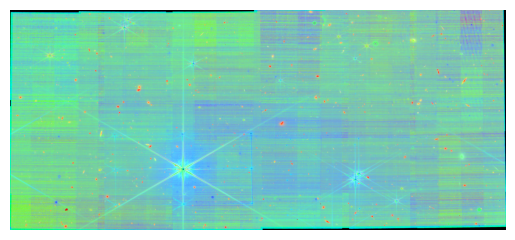

In [31]:
from astropy.io import fits
from reproject import reproject_interp
from astropy.wcs import WCS
from astropy.visualization import make_lupton_rgb
import matplotlib.pyplot as plt
import numpy as np

# Load your FITS files
r_file = '/Users/sshapiro/Desktop/356w DATA.fits'
g_file = '/Users/sshapiro/Desktop/115w DATA.fits'
b_file = '/Users/sshapiro/Desktop/f070w DATA.fits'

r_data, r_header = fits.getdata(r_file, header=True)
g_data, g_header = fits.getdata(g_file, header=True)
b_data, b_header = fits.getdata(b_file, header=True)

# Pick one as reference — red channel works well
ref_wcs = WCS(r_header)
ref_shape = r_data.shape

# Reproject g and b to match r
g_reproj, _ = reproject_interp((g_data, WCS(g_header)), ref_wcs, shape_out=ref_shape)
b_reproj, _ = reproject_interp((b_data, WCS(b_header)), ref_wcs, shape_out=ref_shape)

# Optional: clean NaNs
g_reproj = np.nan_to_num(g_reproj)
b_reproj = np.nan_to_num(b_reproj)

# Build RGB image
rgb_image = make_lupton_rgb(r_data, g_reproj, b_reproj, stretch=0.01, Q=10)

# Show it
plt.imshow(rgb_image, origin='lower')
plt.axis('off')
plt.show()


In [32]:
# the following code is the API equivalent to the series of UI clicks we will do in the live demo
# get the 'Plot Options' plugin
plot_options = imviz.plugins['Plot Options']

# enable mutiselect so our chosen options are applied to all images
plot_options.layer.multiselect = True
plot_options.select_all()

# switch stretch function from default linear to log
plot_options.stretch_function = 'arcsinh'

# use the 99.5% stretch function preset
plot_options.stretch_preset = '99.5%'

# increase vmax to a more suitable value
plot_options.stretch_vmax = 600

In [33]:
# the 'obj' here means that we're using a method not yet exposed as part of the public API
plot_options._obj.image_color_mode_value = 'One color per layer'

plot_options.apply_RGB_presets()

In [34]:
catalogs_plugin = imviz.plugins['Catalog Search']._obj

# select Gaia catalog
catalogs_plugin.catalog.selected = 'Gaia'

# request only 10 sources
catalogs_plugin.max_sources = 10

# and run the search
catalogs_plugin.search()

# select all catalog table entries
catalogs_plugin.table.selected_rows = catalogs_plugin.table.items

# and zoom to region containing these points
catalogs_plugin.zoom_to_selected()

In [35]:
# now select just the first point
catalogs_plugin.table.selected_rows = catalogs_plugin.table.items[0:1]

# and zoom to that point
catalogs_plugin.zoom_to_selected()

In [36]:
from regions import CircleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u

# get the 'Subsets Tools' plugin where we can create and interact with spatial regions in imviz
subset_plugin = imviz.plugins['Subset Tools']

# load a circular region at the location of our selected catalog item
# just for demo sake, shift the coordinates a tiny bit from the catalog position so we
# can use the 'recenter' position. This recreates the scenario of freehand drawing a circular subset
# rather than placing it at an exact location
circular_region = CircleSkyRegion(center=SkyCoord(268.891018, 65.89688, unit='degree'), radius=0.0001*u.deg)
subset_plugin.import_region(circular_region)

In [37]:
# use the 'recenter' function to get our drawn region closer to the center of the source
# call this a few times to converge on a better position
subset_plugin.subset = 'Subset 1'
subset_plugin.recenter()
subset_plugin.recenter()
subset_plugin.recenter()

In [38]:
# get the plugin
aperture_photometry = imviz.plugins['Aperture Photometry']._obj

# enable multiselect mode to do photometry on multiple datasets at once
aperture_photometry.multiselect = True

# select all datasets
aperture_photometry.dataset.select_all()

# select our photometric aperture
aperture_photometry.aperture.selected = 'Subset 1'

# and run photometry to produce output table
aperture_photometry.vue_do_aper_phot()

In [39]:
aperture_photometry.table

Table(events=['clear_table', 'popout'], headers_avail=['xcenter', 'ycenter', 'sky_center', 'sum', 'sum_aper_ar…